# Dynamics and Predictive Power of the Variance Risk Premium in S&P 500 Options
## Part 2 — Econometric Models

**Structure**

1. Setup & Data Loading
2. Benchmark Models (Time-Series Family)
   - 2.1 Historical Mean
   - 2.2 HAR (Corsi, 2009)
   - 2.3 EGARCH
3. Option-Implied Models
   - 3.1 OLS — Nested Models (ATM IV, Skew, Convexity, VIX)
   - 3.2 Mincer-Zarnowitz Test on IV
   - 3.3 Encompassing Regression (HAR vs IV)
4. PCA of the Volatility Surface
5. Panel Models (IV Surface)
   - 5.1 Pooled OLS
   - 5.2 Fixed Effects (within estimator)
   - 5.3 Random Effects + Hausman Test
6. Out-of-Sample Forecast Evaluation
   - 6.1 Rolling Window Forecasts
   - 6.2 Error Metrics (RMSE, MAE, QLIKE)
   - 6.3 Diebold-Mariano Tests


## 1 · Setup & Data Loading

In [175]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import brentq
import warnings, os, glob
from statsmodels.stats.diagnostic import acorr_breusch_godfrey, het_white
from statsmodels.stats.stattools import durbin_watson
import statsmodels.api as sm
from scipy import stats
import yfinance as yf 
import pickle

from utilities.ts_construction import extract_daily_metrics
from utilities.linear_regression import ols, reg_table
from utilities.fixed_random_effects import within_estimator, build_surface_panel


In [176]:
# ── Pour recharger dans un autre notebook ─────────────────────────────────────
with open('time_series.pkl', 'rb') as f:
    ts = pickle.load(f)
reg_overlap    = ts['reg_overlap']
reg_nonoverlap = ts['reg_nonoverlap']
metrics        = ts['metrics']
df             = ts['df']
spot_ts         = ts['spot_ts']
log_ret       = ts['log_ret']

In [177]:
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'font.family': 'DejaVu Sans',
})

# ── User settings ──────────────────────────────────────────────────────────────
DATA_FOLDER   = './data'        # folder containing all YYYY-MM-DD.csv files
TARGET_TENOR  = 30              # target tenor in days for daily metrics
WING_LOW      = -0.15           # put-wing lower bound (log-moneyness)
WING_HIGH_PUT = -0.05           # put-wing upper bound
WING_LOW_CALL =  0.05           # call-wing lower bound
WING_HIGH     =  0.15           # call-wing upper bound
RV_WINDOW     = 21              # rolling window for realized vol (trading days)

print("Libraries loaded")

Libraries loaded


In [178]:
# ── Import VIX ─────────────────────────────────────────────────────────────────
vix = yf.Ticker("^VIX")
hist = vix.history(start="2017-06-09", end="2018-06-08")
Vix_close = hist["Close"]
Vix_close.index = Vix_close.index.tz_localize(None)

# ── Overlapping ────────────────────────────────────────────────────────────────
reg = reg_overlap.copy()
reg = reg.join(Vix_close.rename("vix"), how="left")
reg['vix_norm']       = reg['vix'] / 100
reg['vix_atm_spread'] = reg['vix_norm'] - reg['atm_iv']

# ── Non-overlapping ────────────────────────────────────────────────────────────
reg_no = reg_nonoverlap.copy()
reg_no = reg_no.join(Vix_close.rename("vix"), how="left")
reg_no['vix_norm']       = reg_no['vix'] / 100
reg_no['vix_atm_spread'] = reg_no['vix_norm'] - reg_no['atm_iv']

print(f"Overlapping    : N = {len(reg.dropna(subset=['vix']))}")
print(f"Non-overlapping: N = {len(reg_no.dropna(subset=['vix']))}")


Overlapping    : N = 211
Non-overlapping: N = 11


## 2 · Benchmark Models — Time-Series Family

These models use **only past volatility** (no option information). 
They serve as the baseline against which option-implied models must demonstrate incremental predictive power.

| Model | Regressors |
|-------|------------|
| Historical Mean | constant only |
| HAR | RV daily, weekly, monthly |
| EGARCH | conditional variance from return dynamics |

### 2.1 Historical Mean (Naïve Benchmark)

A constant-only forecast: $\widehat{RV}_{t+21} = \bar{RV}$. Any model that fails to beat this is uninformative.

In [179]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy import stats

# Historical mean on the overlapping series
y_full = reg_overlap['rv_forward'].dropna()
hist_mean = y_full.mean()
hist_resid = y_full - hist_mean
hist_rmse = np.sqrt(np.mean(hist_resid**2))
hist_mae  = np.mean(np.abs(hist_resid))
print(f'Historical Mean forecast : {hist_mean:.4f}')
print(f'RMSE : {hist_rmse:.4f}  |  MAE : {hist_mae:.4f}')

Historical Mean forecast : 0.1166
RMSE : 0.0804  |  MAE : 0.0660


### 2.2 HAR Model (Corsi, 2009)

The HAR model captures the multi-horizon persistence of realized volatility:

$$RV^{\\text{fwd}}_t = \\beta_0 + \\beta_d RV^d_t + \\beta_w RV^w_t + \\beta_m RV^m_t + \\varepsilon_t$$

where $RV^d$, $RV^w$, $RV^m$ are daily, 5-day, and 21-day rolling averages. 
We work in **variance** space (squared quantities) following Andersen et al. (2003).

> **Note on the RV proxy**: we use $r_t^2 \\times 252$ as a daily variance proxy. 
This is noisy relative to a true intraday-based RV but is the only measure available with our data.

In [180]:
import matplotlib.dates as mdates

Observations : 211
Période      : 2017-07-10 → 2018-05-09

Statistiques descriptives (variance annualisée) :
           rv_d      rv_w      rv_m  var_forward    iv_var
count  211.0000  211.0000  211.0000     211.0000  211.0000
mean     0.0193    0.0193    0.0190       0.0201    0.0182
std      0.0686    0.0428    0.0257       0.0265    0.0173
min      0.0000    0.0001    0.0011       0.0009    0.0055
25%      0.0002    0.0021    0.0031       0.0037    0.0111
50%      0.0019    0.0066    0.0052       0.0081    0.0142
75%      0.0130    0.0157    0.0245       0.0240    0.0200
max      0.8642    0.3018    0.0938       0.0974    0.2265

  Tests de stationnarité (ADF + KPSS)
rv_d            ADF p=0.000  KPSS p=0.029  [attention]
rv_w            ADF p=0.139  KPSS p=0.029  [attention]
rv_m            ADF p=0.161  KPSS p=0.010  [attention]
var_forward     ADF p=0.151  KPSS p=0.011  [attention]
iv_var          ADF p=0.000  KPSS p=0.010  [attention]

  Model              R²   Adj R²        AIC  

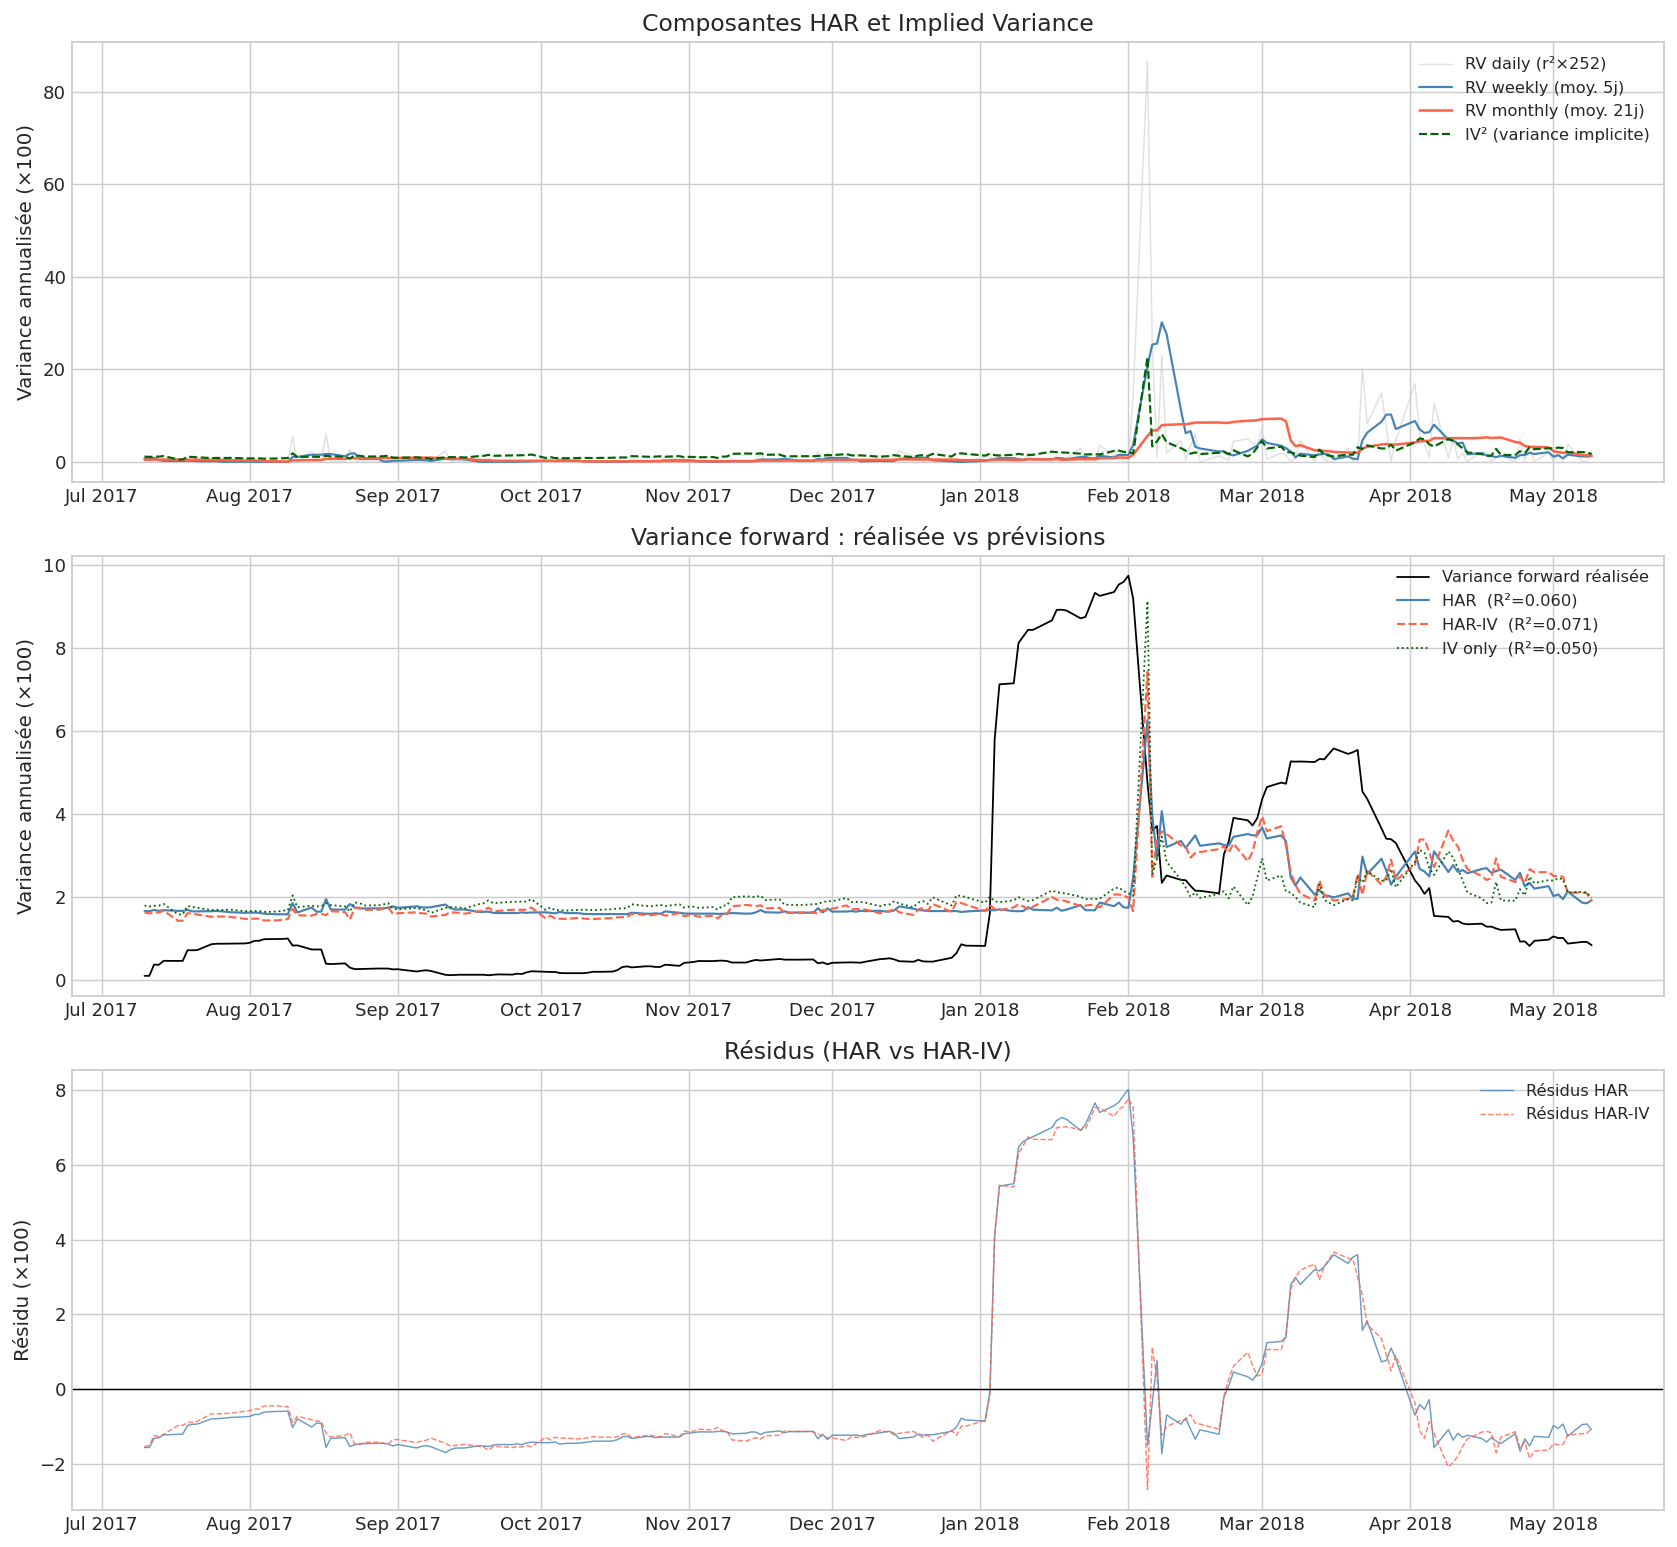

In [181]:
# =============================================================================
# HAR Model (Corsi, 2009) — proxy RV journalière via r_t^2
# =============================================================================


# -----------------------------------------------------------------------------
# 1. Construction des composantes HAR
# -----------------------------------------------------------------------------

# log_ret est dans ton pickle — log-returns journaliers end-of-day
# On travaille en variance annualisée

rv_daily_var = (log_ret ** 2) * 252        # proxy RV journalière annualisée

df_har = pd.DataFrame({
    'rv_d'       : rv_daily_var,
    'rv_w'       : rv_daily_var.rolling(5).mean(),
    'rv_m'       : rv_daily_var.rolling(21).mean(),
}, index=log_ret.index)

# Aligner avec rv_forward et atm_iv depuis reg_overlap
df_har = df_har.join(reg_overlap[['rv_forward', 'atm_iv']], how='inner')

# Variable cible en variance
df_har['var_forward'] = df_har['rv_forward'] ** 2
df_har['iv_var']      = df_har['atm_iv'] ** 2

df_har = df_har.dropna().copy()

print(f"Observations : {len(df_har)}")
print(f"Période      : {df_har.index[0].date()} → {df_har.index[-1].date()}")
print(f"\nStatistiques descriptives (variance annualisée) :")
print(df_har[['rv_d','rv_w','rv_m','var_forward','iv_var']].describe().round(4))

# -----------------------------------------------------------------------------
# 2. Vérification préliminaire : stationnarité
# -----------------------------------------------------------------------------
from statsmodels.tsa.stattools import adfuller, kpss

print("\n" + "="*60)
print("  Tests de stationnarité (ADF + KPSS)")
print("="*60)

for col in ['rv_d', 'rv_w', 'rv_m', 'var_forward', 'iv_var']:
    adf_stat, adf_p, _, _, _, _ = adfuller(df_har[col], autolag='AIC')
    kpss_stat, kpss_p, _, _     = kpss(df_har[col], regression='c', nlags='auto')
    print(f"{col:<14}  ADF p={adf_p:.3f}  KPSS p={kpss_p:.3f}  "
          f"{'[stationnaire]' if adf_p < 0.05 and kpss_p > 0.05 else '[attention]'}")

# -----------------------------------------------------------------------------
# 3. Estimation des modèles
# -----------------------------------------------------------------------------

y = df_har['var_forward']

# AR(1) baseline
X_ar    = sm.add_constant(df_har[['rv_d']])
m_ar    = sm.OLS(y, X_ar).fit(cov_type='HAC', cov_kwds={'maxlags': 21})

# HAR
X_har   = sm.add_constant(df_har[['rv_d', 'rv_w', 'rv_m']])
m_har   = sm.OLS(y, X_har).fit(cov_type='HAC', cov_kwds={'maxlags': 21})

# IV seule
X_iv    = sm.add_constant(df_har[['iv_var']])
m_iv    = sm.OLS(y, X_iv).fit(cov_type='HAC', cov_kwds={'maxlags': 21})

# HAR-IV
X_hariv = sm.add_constant(df_har[['rv_d', 'rv_w', 'rv_m', 'iv_var']])
m_hariv = sm.OLS(y, X_hariv).fit(cov_type='HAC', cov_kwds={'maxlags': 21})

models = [('AR(1)', m_ar), ('HAR', m_har), ('IV only', m_iv), ('HAR-IV', m_hariv)]

# -----------------------------------------------------------------------------
# 4. Tableau comparatif
# -----------------------------------------------------------------------------

print("\n" + "="*65)
print(f"  {'Model':<12} {'R²':>8} {'Adj R²':>8} {'AIC':>10} {'N':>6}")
print("="*65)
for name, m in models:
    print(f"  {name:<12} {m.rsquared:>8.4f} {m.rsquared_adj:>8.4f} "
          f"{m.aic:>10.1f} {int(m.nobs):>6}")
print("="*65)

# Coefficients détaillés
for name, m in models:
    print(f"\n{'─'*58}")
    print(f"  {name}  —  Newey-West HAC (21 lags)")
    print(f"{'─'*58}")
    tbl = pd.DataFrame({
        'coef' : m.params.round(5),
        't'    : m.tvalues.round(2),
        'p'    : m.pvalues.round(3),
        ''     : ['***' if p<0.01 else '**' if p<0.05
                  else '*' if p<0.1 else '' for p in m.pvalues]
    })
    print(tbl.to_string())

# -----------------------------------------------------------------------------
# 5. Tests économétriques sur les résidus
# -----------------------------------------------------------------------------

print("\n" + "="*60)
print("  Diagnostic des résidus — HAR")
print("="*60)

resid_har = m_har.resid

# 5.1 Normalité (Jarque-Bera)
jb_stat, jb_p = stats.jarque_bera(resid_har)
print(f"\nJarque-Bera (normalité)    : stat={jb_stat:.2f}  p={jb_p:.3f}"
      f"  {'[non normal]' if jb_p < 0.05 else '[normal]'}")

# 5.2 Autocorrélation des résidus (Ljung-Box à lag 21)
from statsmodels.stats.diagnostic import acorr_ljungbox
lb = acorr_ljungbox(resid_har, lags=[5, 10, 21], return_df=True)
print(f"\nLjung-Box (autocorrélation résidus) :")
print(lb[['lb_stat', 'lb_pvalue']].round(3).to_string())
print("  → Si p < 0.05 : autocorrélation résiduelle (normale avec fenêtres chevauchantes)")
print("  → Corrigée par Newey-West, pas un problème pour l'inférence")

# 5.3 Hétéroscédasticité (White)
from statsmodels.stats.diagnostic import het_white
white_stat, white_p, _, _ = het_white(resid_har, X_har)
print(f"\nWhite (hétéroscédasticité) : stat={white_stat:.2f}  p={white_p:.3f}"
      f"  {'[hétéroscédastique]' if white_p < 0.05 else '[homoscédastique]'}")
print("  → Si hétéroscédastique : Newey-West corrige l'inférence")

# 5.4 Autocorrélation des résidus carrés (ARCH effects)
from statsmodels.stats.diagnostic import het_arch
arch_stat, arch_p, _, _ = het_arch(resid_har, nlags=5)
print(f"\nARCH LM (effets ARCH)      : stat={arch_stat:.2f}  p={arch_p:.3f}"
      f"  {'[effets ARCH présents]' if arch_p < 0.05 else '[pas deffets ARCH]'}")
print("  → Si ARCH présent : variance conditionnelle non constante")
print("    → justifie GARCH comme modèle concurrent")

# -----------------------------------------------------------------------------
# 6. Tests économiques sur les coefficients
# -----------------------------------------------------------------------------

print("\n" + "="*60)
print("  Tests sur les hypothèses économiques")
print("="*60)

# Test A : IV prédicteur non biaisé (alpha=0, beta=1)
alpha_iv = m_iv.params['const']
beta_iv  = m_iv.params['iv_var']
se_alpha = m_iv.bse['const']
se_beta  = m_iv.bse['iv_var']
t_alpha  = alpha_iv / se_alpha
t_beta   = (beta_iv - 1) / se_beta

print(f"\nA. IV prédicteur non biaisé (modèle IV seul)")
print(f"   H0 : α = 0  →  α={alpha_iv:.4f}  t={t_alpha:.2f}  "
      f"p={m_iv.pvalues['const']:.3f}")
print(f"   H0 : β = 1  →  β={beta_iv:.4f}  t={t_beta:.2f}  "
      f"p={2*(1 - stats.t.cdf(abs(t_beta), df=m_iv.df_resid)):.3f}")

# Test B : IV apporte information au-delà de HAR
g   = m_hariv.params['iv_var']
t_g = m_hariv.tvalues['iv_var']
p_g = m_hariv.pvalues['iv_var']
print(f"\nB. IV marginalement informative au-delà de HAR")
print(f"   H0 : γ(IV) = 0  →  γ={g:.4f}  t={t_g:.2f}  p={p_g:.3f}")
print(f"   → {'IV apporte information au-delà de HAR' if p_g < 0.05 else 'IV non significative cond. à HAR'}")

# Test C : RV passée apporte information au-delà de IV (F-test)
f_test = m_hariv.f_test('(rv_d = 0), (rv_w = 0), (rv_m = 0)')
f_val  = float(f_test.fvalue)
f_p    = float(f_test.pvalue)
print(f"\nC. HAR marginalement informatif au-delà de IV")
print(f"   H0 : β_d = β_w = β_m = 0  →  F={f_val:.2f}  p={f_p:.3f}")
print(f"   → {'RV passée apporte information au-delà de IV' if f_p < 0.05 else 'RV passée non significative cond. à IV'}")

# Test D : HAR vs AR(1) — apport des composantes multi-horizon
f_har = m_har.f_test('(rv_w = 0), (rv_m = 0)')
print(f"\nD. Apport des composantes multi-horizon (HAR vs AR(1))")
print(f"   H0 : β_w = β_m = 0  →  F={float(f_har.fvalue):.2f}  p={float(f_har.pvalue):.3f}")
print(f"   → {'Structure multi-horizon significative' if float(f_har.pvalue) < 0.05 else 'AR(1) suffisant'}")

# -----------------------------------------------------------------------------
# 7. Visualisation
# -----------------------------------------------------------------------------

fig, axes = plt.subplots(3, 1, figsize=(13, 12))

# Panel A : composantes HAR
ax = axes[0]
ax.plot(df_har.index, df_har['rv_d']*100,  color='lightgray', lw=0.8,
        label='RV daily (r²×252)', alpha=0.7)
ax.plot(df_har.index, df_har['rv_w']*100,  color='steelblue', lw=1.2,
        label='RV weekly (moy. 5j)')
ax.plot(df_har.index, df_har['rv_m']*100,  color='tomato',    lw=1.4,
        label='RV monthly (moy. 21j)')
ax.plot(df_har.index, df_har['iv_var']*100, color='darkgreen', lw=1.2,
        ls='--', label='IV² (variance implicite)')
ax.set_title('Composantes HAR et Implied Variance')
ax.set_ylabel('Variance annualisée (×100)')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# Panel B : prévisions vs réalisé
ax = axes[1]
ax.plot(df_har.index, y*100,
        color='black',    lw=1,   label='Variance forward réalisée')
ax.plot(df_har.index, m_har.fittedvalues*100,
        color='steelblue',lw=1.2, label=f'HAR  (R²={m_har.rsquared:.3f})')
ax.plot(df_har.index, m_hariv.fittedvalues*100,
        color='tomato',   lw=1.2, ls='--',
        label=f'HAR-IV  (R²={m_hariv.rsquared:.3f})')
ax.plot(df_har.index, m_iv.fittedvalues*100,
        color='darkgreen',lw=1,   ls=':',
        label=f'IV only  (R²={m_iv.rsquared:.3f})')
ax.set_title('Variance forward : réalisée vs prévisions')
ax.set_ylabel('Variance annualisée (×100)')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# Panel C : résidus
ax = axes[2]
ax.plot(df_har.index, m_har.resid*100,
        color='steelblue', lw=0.8, alpha=0.8, label='Résidus HAR')
ax.plot(df_har.index, m_hariv.resid*100,
        color='tomato',    lw=0.8, alpha=0.8, ls='--', label='Résidus HAR-IV')
ax.axhline(0, color='black', lw=0.8)
ax.set_title('Résidus (HAR vs HAR-IV)')
ax.set_ylabel('Résidu (×100)')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.tight_layout()
plt.show()

### 2.3 EGARCH(1,1)

EGARCH captures the asymmetric response of volatility to negative vs positive return shocks (leverage effect), 
which standard GARCH cannot:

$$\\log \\sigma^2_t = \\omega + \\alpha \\left(\\frac{|\\varepsilon_{t-1}|}{\\sigma_{t-1}} - \\sqrt{\\frac{2}{\\pi}}\\right) + \\gamma \\frac{\\varepsilon_{t-1}}{\\sigma_{t-1}} + \\beta \\log \\sigma^2_{t-1}$$

$\\gamma < 0$ is the leverage effect. We use log-returns of the S&P 500 underlying.

In [182]:
from arch import arch_model

# Fit EGARCH(1,1) on log-returns
ret_series = log_ret.dropna() * 100   # arch_model expects % returns for numerical stability
egarch = arch_model(ret_series, vol='EGARCH', p=1, q=1, dist='Normal')
res_egarch = egarch.fit(disp='off')
print(res_egarch.summary())

# Annualised conditional volatility forecast
egarch_vol = np.sqrt(res_egarch.conditional_volatility ** 2 * 252) / 100
egarch_vol.name = 'egarch_vol'
print(f'\nLeverage effect γ = {res_egarch.params["alpha[1]"]:.4f}  ',
      f'(p = {res_egarch.pvalues["alpha[1]"]:.4f})')

                     Constant Mean - EGARCH Model Results                     
Dep. Variable:                   spot   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                     EGARCH   Log-Likelihood:               -239.907
Distribution:                  Normal   AIC:                           487.814
Method:            Maximum Likelihood   BIC:                           501.931
                                        No. Observations:                  252
Date:                Wed, Jun 10 2026   Df Residuals:                      251
Time:                        17:55:28   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.1521  3.270e-02      4.651  3.296e-06 [8.802e-0

## 3 · Option-Implied Models

We test whether the implied volatility surface contains predictive information for future RV **beyond** what past RV alone captures. 
All regressions use Newey-West (HAC) standard errors with 20 lags to correct for the overlapping-window autocorrelation induced by the 21-day forward RV.

### 3.1 OLS — Nested Models

**Dependent variable**: $RV^{\\text{fwd}}_t$ — annualised realised volatility over the 21 trading days following day $t$.

$$RV^{\\text{fwd}}_t = \\sqrt{252} \\cdot \\hat{\\sigma}(r_{t+1}, \\ldots, r_{t+21})$$

We estimate four nested models:

| Model | Specification |
|-------|---------------|
| M1 | ATM IV |
| M2 | ATM IV + Skew |
| M3 | ATM IV + Skew + Convexity |
| M4 | ATM IV + Skew + Convexity + VIX–ATM spread |

In [183]:
y = reg_overlap['rv_forward']

In [184]:
print("═"*62)
print("MODEL 1 — Baseline: RV_fwd ~ ATM_IV")
print("═"*62)
r1 = ols(y, reg[['atm_iv']])
reg_table(r1, ['Const', 'ATM_IV'])

══════════════════════════════════════════════════════════════
MODEL 1 — Baseline: RV_fwd ~ ATM_IV
══════════════════════════════════════════════════════════════

──────────────────────────────────────────────────────────────
Variable                    Coef        SE        t         p
──────────────────────────────────────────────────────────────
Const                     0.0112    0.0171    0.658    0.5114 
ATM_IV                    0.8192    0.1266    6.471    0.0000 ***
──────────────────────────────────────────────────────────────
R²                        0.1669
Adj. R²                   0.1629
N                            211
──────────────────────────────────────────────────────────────
Significance: * p<0.05  ** p<0.01  *** p<0.001


In [185]:
print("\n" + "═"*62)
print("MODEL 2 — RV_fwd ~ ATM_IV + Skew")
print("═"*62)
r2 = ols(y, reg[['atm_iv', 'skew']])
reg_table(r2, ['Const', 'ATM_IV', 'Skew'])


══════════════════════════════════════════════════════════════
MODEL 2 — RV_fwd ~ ATM_IV + Skew
══════════════════════════════════════════════════════════════

──────────────────────────────────────────────────────────────
Variable                    Coef        SE        t         p
──────────────────────────────────────────────────────────────
Const                     0.0603    0.0213    2.838    0.0051 **
ATM_IV                    0.9124    0.1544    5.909    0.0000 ***
Skew                     -0.6913    0.2221   -3.112    0.0022 **
──────────────────────────────────────────────────────────────
R²                        0.1798
Adj. R²                   0.1695
N                            163
──────────────────────────────────────────────────────────────
Significance: * p<0.05  ** p<0.01  *** p<0.001


In [186]:
print("\n" + "═"*62)
print("MODEL 3 — RV_fwd ~ ATM_IV + Skew + Convexity")
print("═"*62)
r3 = ols(y, reg[['atm_iv', 'skew', 'convexity']])
reg_table(r3, ['Const', 'ATM_IV', 'Skew', 'Convexity'])


══════════════════════════════════════════════════════════════
MODEL 3 — RV_fwd ~ ATM_IV + Skew + Convexity
══════════════════════════════════════════════════════════════

──────────────────────────────────────────────────────────────
Variable                    Coef        SE        t         p
──────────────────────────────────────────────────────────────
Const                     0.0183    0.0300    0.611    0.5424 
ATM_IV                    1.1146    0.1845    6.043    0.0000 ***
Skew                     -0.7201    0.2207   -3.263    0.0013 **
Convexity                 0.6475    0.3296    1.965    0.0512 
──────────────────────────────────────────────────────────────
R²                        0.1992
Adj. R²                   0.1841
N                            163
──────────────────────────────────────────────────────────────
Significance: * p<0.05  ** p<0.01  *** p<0.001


In [187]:
reg['vix_atm_spread'] = reg['vix_norm'] - reg['atm_iv']

# Reconstruire y proprement sur le bon index
y = reg['rv_forward'].dropna()
common_idx = y.index.intersection(
    reg[['atm_iv', 'skew', 'convexity', 'vix_atm_spread']].dropna().index
)
y_clean = y.loc[common_idx]
X_clean = reg.loc[common_idx, ['atm_iv', 'skew', 'convexity', 'vix_atm_spread']]

r6 = ols(y_clean, X_clean)
reg_table(r6, ['Const', 'ATM_IV', 'Skew', 'Convexity', 'VIX_ATM_Spread'])


──────────────────────────────────────────────────────────────
Variable                    Coef        SE        t         p
──────────────────────────────────────────────────────────────
Const                     0.1150    0.0443    2.593    0.0104 *
ATM_IV                    0.6688    0.2367    2.826    0.0053 **
Skew                     -0.7545    0.2160   -3.493    0.0006 ***
Convexity                -0.9389    0.6337   -1.482    0.1404 
VIX_ATM_Spread            1.0241    0.3523    2.907    0.0042 **
──────────────────────────────────────────────────────────────
R²                        0.2399
Adj. R²                   0.2206
N                            163
──────────────────────────────────────────────────────────────
Significance: * p<0.05  ** p<0.01  *** p<0.001


In [188]:
data  = reg[['atm_iv', 'skew', 'convexity' , 'vix_atm_spread' ,'rv_forward']].dropna()
X_m6  = sm.add_constant(data[['atm_iv', 'skew', 'convexity' , 'vix_atm_spread']].values)
y_m6  = data['rv_forward'].values

res_nw  = sm.OLS(y_m6, X_m6).fit(cov_type='HAC', cov_kwds={'maxlags': 20})

print(res_nw.summary())

jb_stat,    jb_p          = stats.jarque_bera(res_nw.resid)
dw                         = durbin_watson(res_nw.resid)
bg_stat,    bg_p,   _, _  = acorr_breusch_godfrey(res_nw, nlags=21)
white_stat, white_p, _, _ = het_white(res_nw.resid, X_m6)

print(f"Jarque-Bera     : stat={jb_stat:.3f}  p={jb_p:.4f}  "
      f"{'reject normality'          if jb_p    < 0.05 else 'cannot reject normality'}")
print(f"Durbin-Watson   : {dw:.4f}            "
      f"{'autocorrelation present'   if abs(dw-2)>0.5  else 'no strong autocorrelation'}")
print(f"White           : stat={white_stat:.3f}  p={white_p:.4f}  "
      f"{'reject homoscedasticity'   if white_p < 0.05 else 'cannot reject homoscedasticity'}")
print(f"Breusch-Godfrey : stat={bg_stat:.3f}  p=  {bg_p:.4f}  "
      f"{'reject no autocorrelation' if bg_p    < 0.05 else 'cannot reject no autocorrelation'}")

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.240
Model:                            OLS   Adj. R-squared:                  0.221
Method:                 Least Squares   F-statistic:                     3.936
Date:                Wed, 10 Jun 2026   Prob (F-statistic):            0.00449
Time:                        17:55:28   Log-Likelihood:                 201.76
No. Observations:                 163   AIC:                            -393.5
Df Residuals:                     158   BIC:                            -378.1
Df Model:                           4                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1150      0.065      1.767      0.0

### 3.2 Mincer-Zarnowitz Test

Standard test for forecast unbiasedness:

$$RV^{\\text{realized}}_t = \\alpha + \\beta \\cdot \\widehat{RV}_t + u_t$$

Joint test $H_0: \\alpha = 0, \\beta = 1$. Rejection means the forecast is biased. 
In practice $\\beta < 1$ and $\\alpha > 0$ reflects the systematic Variance Risk Premium: 
implied volatility overestimates future realised volatility on average.

In [189]:
# Mincer-Zarnowitz on the ATM IV model (M1)
y_mz = reg_overlap['rv_forward'].dropna()
X_mz = sm.add_constant(reg_overlap['atm_iv'].reindex(y_mz.index).dropna())
y_mz = y_mz.reindex(X_mz.index)

res_mz = sm.OLS(y_mz, X_mz).fit(cov_type='HAC', cov_kwds={'maxlags': 20})
alpha, beta = res_mz.params
se_alpha, se_beta = res_mz.bse

t_alpha = alpha / se_alpha
t_beta  = (beta - 1) / se_beta
p_alpha = 2 * (1 - stats.t.cdf(abs(t_alpha), df=res_mz.df_resid))
p_beta  = 2 * (1 - stats.t.cdf(abs(t_beta),  df=res_mz.df_resid))

print('═'*55)
print('Mincer-Zarnowitz : IV as unbiased predictor of RV')
print('═'*55)
print(f'α = {alpha:.4f}   t = {t_alpha:.2f}   p = {p_alpha:.4f}  ',
      f'  {"reject H0: α=0" if p_alpha < 0.05 else "cannot reject α=0"}')
print(f'β = {beta:.4f}   t = {t_beta:.2f}   p = {p_beta:.4f}  ',
      f'  {"reject H0: β=1" if p_beta  < 0.05 else "cannot reject β=1"}')
print(f'\nInterpretation: IV {"over-estimates" if alpha > 0 and beta < 1 else "is an unbiased predictor of"} future RV → VRP is {"positive" if alpha > 0 else "zero"} on average')

═══════════════════════════════════════════════════════
Mincer-Zarnowitz : IV as unbiased predictor of RV
═══════════════════════════════════════════════════════
α = 0.0112   t = 0.30   p = 0.7680     cannot reject α=0
β = 0.8192   t = -0.84   p = 0.3991     cannot reject β=1

Interpretation: IV over-estimates future RV → VRP is positive on average


### 3.3 Encompassing Regression (HAR vs IV)

Does implied volatility add information **beyond** what past realised volatility (HAR) already contains? 
And vice versa?

$$RV^{\\text{fwd}}_t = \\alpha + \\beta_1 \\widehat{RV}^{\\text{HAR}}_t + \\beta_2 \\widehat{RV}^{\\text{IV}}_t + u_t$$

If $\\beta_2 > 0$ and significant: IV contains information not spanned by HAR. 
If both coefficients are significant: neither model encompasses the other.

In [190]:
# Build HAR fitted values on the overlapping sample
rv_daily_var = (log_ret ** 2) * 252
df_enc = pd.DataFrame({
    'rv_d': rv_daily_var,
    'rv_w': rv_daily_var.rolling(5).mean(),
    'rv_m': rv_daily_var.rolling(21).mean(),
}).join(reg_overlap[['rv_forward', 'atm_iv']], how='inner').dropna()

df_enc['var_forward'] = df_enc['rv_forward'] ** 2
df_enc['iv_var']      = df_enc['atm_iv'] ** 2

# HAR fitted values
X_har_enc = sm.add_constant(df_enc[['rv_d', 'rv_w', 'rv_m']])
m_har_enc = sm.OLS(df_enc['var_forward'], X_har_enc).fit(cov_type='HAC', cov_kwds={'maxlags': 21})
df_enc['har_fitted'] = m_har_enc.fittedvalues

# IV fitted values
X_iv_enc = sm.add_constant(df_enc[['iv_var']])
m_iv_enc = sm.OLS(df_enc['var_forward'], X_iv_enc).fit(cov_type='HAC', cov_kwds={'maxlags': 21})
df_enc['iv_fitted'] = m_iv_enc.fittedvalues

# Encompassing regression
X_enc = sm.add_constant(df_enc[['har_fitted', 'iv_fitted']])
m_enc = sm.OLS(df_enc['var_forward'], X_enc).fit(cov_type='HAC', cov_kwds={'maxlags': 21})
print(m_enc.summary())
print()
print('β_HAR =', round(m_enc.params['har_fitted'], 4),
      '  p =', round(m_enc.pvalues['har_fitted'], 4))
print('β_IV  =', round(m_enc.params['iv_fitted'],  4),
      '  p =', round(m_enc.pvalues['iv_fitted'],  4))
print()
print('→ IV adds information beyond HAR:', m_enc.pvalues['iv_fitted'] < 0.05)
print('→ HAR adds information beyond IV:', m_enc.pvalues['har_fitted'] < 0.05)

                            OLS Regression Results                            
Dep. Variable:            var_forward   R-squared:                       0.065
Model:                            OLS   Adj. R-squared:                  0.056
Method:                 Least Squares   F-statistic:                     3.603
Date:                Wed, 10 Jun 2026   Prob (F-statistic):             0.0290
Time:                        17:55:28   Log-Likelihood:                 474.00
No. Observations:                 211   AIC:                            -942.0
Df Residuals:                     208   BIC:                            -932.0
Df Model:                           2                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0031      0.015     -0.202      0.8

## 4 · PCA of the Volatility Surface

Rather than summarising the surface by hand-crafted statistics (ATM IV, skew, convexity), 
we extract the latent factor structure via PCA. This is consistent with the literature on IV surface dynamics 
(Cont & da Fonseca, 2002; Skiadopoulos et al., 1999).

Standard interpretation:
- **PC1** — level: parallel shift of the surface
- **PC2** — term structure / skew: tilt across strikes or maturities
- **PC3** — curvature (smile)

We then test whether these factors predict $RV^{\\text{fwd}}$ beyond ATM IV alone.

In [191]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Build strike×maturity IV panel — one row per date
# Pivot: rows = dates, columns = (moneyness_bin, maturity_bin)
panel_pca = build_surface_panel(df, reg_overlap,
                                 wing_lo=WING_LOW, wing_hi_p=WING_HIGH_PUT,
                                 wing_lo_c=WING_LOW_CALL, wing_hi=WING_HIGH)

# Pivot to wide format: each (expiry) becomes a column
iv_wide = panel_pca.pivot_table(index='date', columns='expiry', values='atm_iv')
iv_wide = iv_wide.fillna(iv_wide.mean())

print(f'Surface panel: {iv_wide.shape[0]} dates × {iv_wide.shape[1]} expiry columns')

# Standardise and fit PCA
scaler = StandardScaler()
iv_scaled = scaler.fit_transform(iv_wide)

pca = PCA(n_components=5)
factors = pca.fit_transform(iv_scaled)

print('\nExplained variance ratio:')
for i, r in enumerate(pca.explained_variance_ratio_):
    print(f'  PC{i+1}: {r:.3f}  (cumulative: {pca.explained_variance_ratio_[:i+1].sum():.3f})')

df_pca = pd.DataFrame(factors[:, :3], index=iv_wide.index,
                       columns=['PC1_level', 'PC2_skew', 'PC3_curv'])
df_pca = df_pca.join(reg_overlap['rv_forward'], how='inner').dropna()

Surface panel: 211 dates × 21 expiry columns

Explained variance ratio:
  PC1: 0.427  (cumulative: 0.427)
  PC2: 0.112  (cumulative: 0.539)
  PC3: 0.080  (cumulative: 0.618)
  PC4: 0.056  (cumulative: 0.675)
  PC5: 0.048  (cumulative: 0.722)


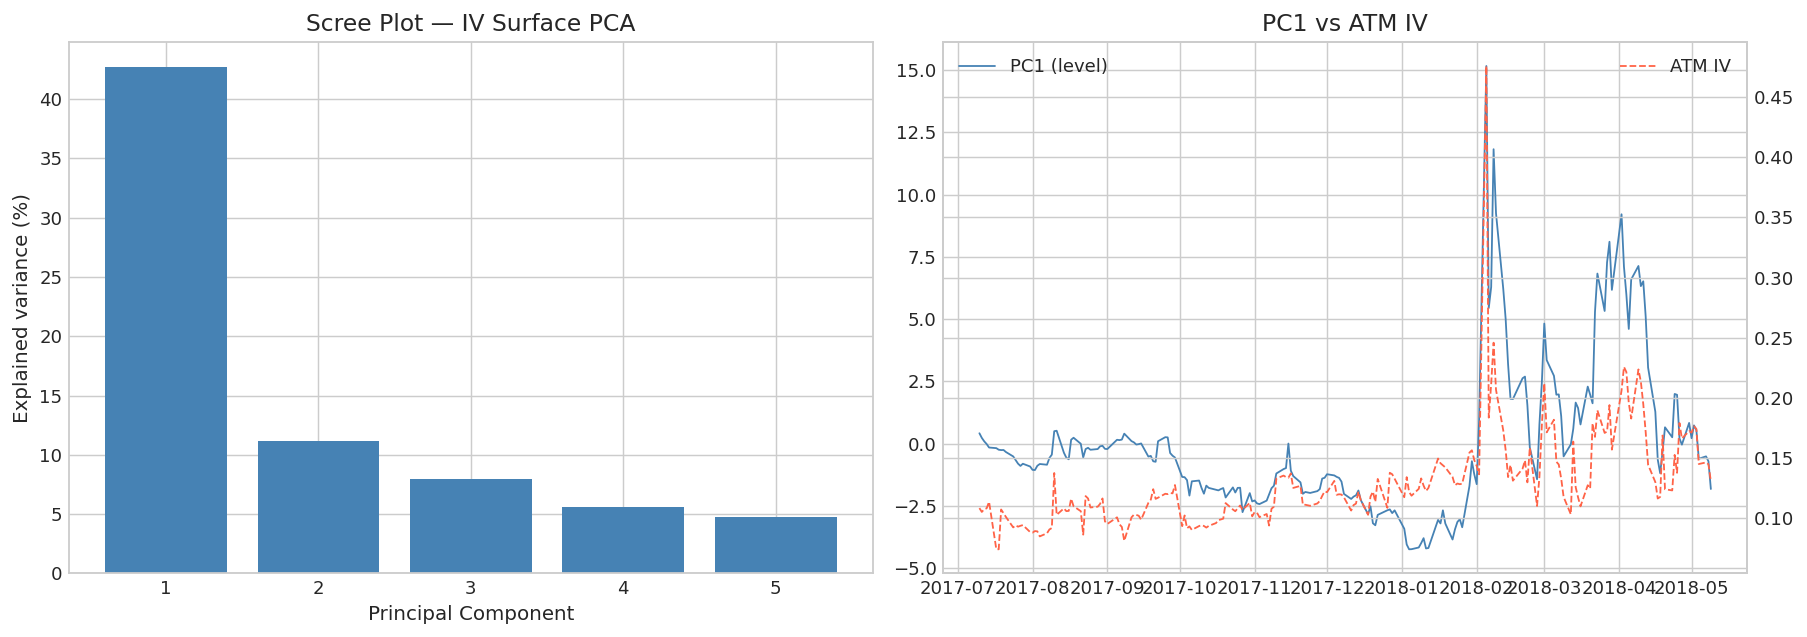

                            OLS Regression Results                            
Dep. Variable:             rv_forward   R-squared:                       0.137
Model:                            OLS   Adj. R-squared:                  0.125
Method:                 Least Squares   F-statistic:                     4.720
Date:                Wed, 10 Jun 2026   Prob (F-statistic):            0.00330
Time:                        17:55:30   Log-Likelihood:                 248.11
No. Observations:                 211   AIC:                            -488.2
Df Residuals:                     207   BIC:                            -474.8
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1166      0.020      5.896      0.0

In [192]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].bar(range(1, 6), pca.explained_variance_ratio_ * 100, color='steelblue')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained variance (%)')
axes[0].set_title('Scree Plot — IV Surface PCA')

# PC1 vs ATM IV
axes[1].plot(df_pca.index, df_pca['PC1_level'], color='steelblue', lw=1, label='PC1 (level)')
ax2 = axes[1].twinx()
ax2.plot(reg_overlap['atm_iv'].reindex(df_pca.index), color='tomato', lw=1, ls='--', label='ATM IV')
axes[1].set_title('PC1 vs ATM IV')
axes[1].legend(loc='upper left')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.show()

# Regression: PCA factors → RV forward
X_pca = sm.add_constant(df_pca[['PC1_level', 'PC2_skew', 'PC3_curv']])
y_pca = df_pca['rv_forward']
m_pca = sm.OLS(y_pca, X_pca).fit(cov_type='HAC', cov_kwds={'maxlags': 20})
print(m_pca.summary())

## 5 · Panel Models — IV Surface

The IV surface is a panel: we observe implied volatility at multiple expiries for each date. 
A pooled OLS confounds the causal relationship (when IV rises, does RV rise?) with the term structure (long-dated options structurally have higher IV). 
Fixed effects absorb the expiry-level intercepts.

### 5.1 Pooled OLS (baseline)

Ignores entity structure. Coefficient will be biased if expiry effects correlate with regressors.

In [193]:
from linearmodels.panel import PanelOLS, RandomEffects

panel_surf = build_surface_panel(df, reg_overlap,
                                  wing_lo=WING_LOW, wing_hi_p=WING_HIGH_PUT,
                                  wing_lo_c=WING_LOW_CALL, wing_hi=WING_HIGH)

vix_norm = reg['vix'] / 100
panel_surf['vix_norm']      = panel_surf['date'].map(vix_norm)
panel_surf['vix_atm_spread'] = panel_surf['vix_norm'] - panel_surf['atm_iv']
panel_surf = panel_surf.dropna(subset=['vix_atm_spread'])

x_cols = ['atm_iv', 'vix_atm_spread']
print(f'Panel: {len(panel_surf)} obs  |  {panel_surf["expiry"].nunique()} expiries  |  {panel_surf["date"].nunique()} dates')

# Pooled OLS
r_pooled = ols(panel_surf['rv_forward'].values, panel_surf[x_cols].values)
print('\nPooled OLS:')
print(f'  R² = {r_pooled["r2"]:.4f}')

Panel: 2240 obs  |  21 expiries  |  211 dates

Pooled OLS:
  R² = 0.1567


### 5.2 Fixed Effects (Within Estimator)

$$\\widetilde{RV}_{it} = \\beta_1 \\widetilde{IV}_{it} + \\beta_2 \\widetilde{\\text{VIX-spread}}_{it} + \\varepsilon_{it}$$

where $\\tilde{x}_{it} = x_{it} - \\bar{x}_i$ (demeaned within each expiry). 
The F-test below assesses whether entity effects are jointly significant.

In [194]:
# F-test for entity fixed effects
fe_surf = within_estimator(panel_surf, 'rv_forward', x_cols, 'expiry')
N, NT, K = panel_surf['expiry'].nunique(), len(panel_surf), len(x_cols)
F_stat = ((np.sum(r_pooled['resid']**2) - np.sum(fe_surf.resid**2)) / (N-1)) / \
          (np.sum(fe_surf.resid**2) / (NT - N - K))
F_p = 1 - stats.f.cdf(F_stat, N-1, NT-N-K)
print(f'F-test entity effects : F = {F_stat:.3f},  p = {F_p:.4f}  → {"Significant ✓" if F_p < 0.05 else "Not significant"}')

# FE and RE estimation
panel_idx = panel_surf.set_index(['expiry', 'date'])
y_pan = panel_idx['rv_forward']
X_pan = sm.add_constant(panel_idx[x_cols])

fe_lm = PanelOLS(y_pan, X_pan[x_cols], entity_effects=True).fit()
print('\n' + '═'*62)
print('FIXED EFFECTS')
print(fe_lm.summary.tables[1])

F-test entity effects : F = 17.040,  p = 0.0000  → Significant ✓

══════════════════════════════════════════════════════════════
FIXED EFFECTS
                               Parameter Estimates                                
                Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
----------------------------------------------------------------------------------
atm_iv             0.0026     0.0867     0.0295     0.9765     -0.1674      0.1726
vix_atm_spread     0.6518     0.0517     12.600     0.0000      0.5504      0.7533


### 5.3 Random Effects + Hausman Test

Random effects assumes $\\alpha_i \\sim \\mathcal{N}(0, \\sigma^2_\\alpha)$ uncorrelated with regressors. 
The Hausman test checks this assumption:

$$H = (\\hat{\\beta}_{FE} - \\hat{\\beta}_{RE})^\\top [\\text{Var}(\\hat{\\beta}_{FE}) - \\text{Var}(\\hat{\\beta}_{RE})]^{-1} (\\hat{\\beta}_{FE} - \\hat{\\beta}_{RE}) \\sim \\chi^2(K)$$

- **Reject $H_0$**: expiry effects correlated with regressors → FE is the only consistent estimator
- **Fail to reject**: RE consistent and more efficient → prefer RE

In [195]:
re_lm = RandomEffects(y_pan, X_pan).fit()
print('RANDOM EFFECTS')
print(re_lm.summary.tables[1])

# Hausman test
b_fe = fe_lm.params.values
b_re = re_lm.params[x_cols].values
V_fe = fe_lm.cov.values
V_re = re_lm.cov.loc[x_cols, x_cols].values
diff = b_fe - b_re
H    = float(diff @ np.linalg.inv(V_fe - V_re) @ diff)
p    = 1 - stats.chi2.cdf(H, df=len(b_fe))
print(f'\nHausman : stat = {H:.4f}  p = {p:.4f}')
print(f'→ {"Reject RE — use FE" if p < 0.05 else "Cannot reject RE — prefer RE"}')

RANDOM EFFECTS
                               Parameter Estimates                                
                Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
----------------------------------------------------------------------------------
const              0.0965     0.0124     7.7706     0.0000      0.0722      0.1209
atm_iv             0.1506     0.0832     1.8099     0.0705     -0.0126      0.3138
vix_atm_spread     0.6226     0.0514     12.120     0.0000      0.5219      0.7233

Hausman : stat = 12.9536  p = 0.0015
→ Reject RE — use FE


## 6 · Out-of-Sample Forecast Evaluation

In-sample $R^2$ is insufficient: a model can overfit. 
We evaluate all models on their **out-of-sample** forecasting performance using a rolling-window scheme.

**Protocol**: train on the first 80% of non-overlapping observations, test on the remaining 20%.

> **Why non-overlapping for evaluation?** Using overlapping observations in the test set would induce 
artificial autocorrelation in forecast errors, inflating apparent precision. 
We train on overlapping data (more observations) but evaluate on non-overlapping data (independent errors).

### 6.1 Rolling Window Forecasts

In [196]:
from sklearn.linear_model import LinearRegression

eval_df = reg_overlap.copy()
eval_df = eval_df.join(Vix_close.rename('vix'), how='left')
eval_df['vix_norm']       = eval_df['vix'] / 100
eval_df['vix_atm_spread'] = eval_df['vix_norm'] - eval_df['atm_iv']

rv_d_no = (log_ret ** 2 * 252).reindex(eval_df.index)
eval_df['rv_d'] = rv_d_no
eval_df['rv_w'] = rv_d_no.rolling(5).mean()
eval_df['rv_m'] = rv_d_no.rolling(21).mean()
eval_df = eval_df.dropna(subset=['rv_forward', 'atm_iv', 'rv_past', 'vix_atm_spread', 'rv_d', 'rv_w', 'rv_m'])

n = len(eval_df)
split = int(n * 0.80)
train, test = eval_df.iloc[:split], eval_df.iloc[split:]
print(f'Train: {len(train)} obs  ({train.index[0].date()} → {train.index[-1].date()})')
print(f'Test : {len(test)} obs  ({test.index[0].date()} → {test.index[-1].date()})')

def oos_predict(X_train, y_train, X_test):
    model = sm.OLS(y_train, sm.add_constant(X_train)).fit()
    return model.predict(sm.add_constant(X_test, has_constant='add'))

y_test = test['rv_forward'].values

forecasts = {}
forecasts['HistMean'] = np.full(len(test), train['rv_forward'].mean())
forecasts['IV']       = oos_predict(train[['atm_iv']], train['rv_forward'], test[['atm_iv']])
forecasts['HAR']      = oos_predict(train[['rv_d','rv_w','rv_m']], train['rv_forward'], test[['rv_d','rv_w','rv_m']])
forecasts['HAR_IV']   = oos_predict(train[['rv_d','rv_w','rv_m','atm_iv']], train['rv_forward'],
                                     test[['rv_d','rv_w','rv_m','atm_iv']])
forecasts['PCA']      = oos_predict(
    df_pca[['PC1_level','PC2_skew','PC3_curv']].reindex(train.index).dropna(),
    reg_overlap['rv_forward'].reindex(train.index).dropna().reindex(
        df_pca[['PC1_level']].reindex(train.index).dropna().index),
    df_pca[['PC1_level','PC2_skew','PC3_curv']].reindex(test.index).dropna()
) if len(df_pca.reindex(test.index).dropna()) > 0 else None

print('\nForecasts computed.')

Train: 152 obs  (2017-08-07 → 2018-03-14)
Test : 39 obs  (2018-03-15 → 2018-05-09)

Forecasts computed.


### 6.2 Error Metrics — RMSE, MAE, QLIKE

We report three loss functions:
- **RMSE** and **MAE**: symmetric, standard.
- **QLIKE**: $\\sum \\left(\\frac{RV}{\\hat{RV}} - \\log\\frac{RV}{\\hat{RV}} - 1\\right)$, asymmetric loss function 
preferred in the volatility forecasting literature (Patton, 2011) because it penalises under-forecasting more severely, 
which matters for risk management.

In [197]:
def rmse(y, yhat): return np.sqrt(np.mean((y - yhat)**2))
def mae(y, yhat):  return np.mean(np.abs(y - yhat))
def qlike(y, yhat):
    yhat = np.maximum(yhat, 1e-8)   # avoid log(0)
    return np.mean(y / yhat - np.log(y / yhat) - 1)

print('{:<12}  {:>10}  {:>10}  {:>10}'.format('Model', 'RMSE', 'MAE', 'QLIKE'))
print('─'*46)
metrics_oos = {}
for name, fc in forecasts.items():
    if fc is None: continue
    y_eval = y_test[:len(fc)]
    r, m, q = rmse(y_eval, fc), mae(y_eval, fc), qlike(y_eval, fc)
    metrics_oos[name] = (r, m, q)
    print(f'{name:<12}  {r:>10.4f}  {m:>10.4f}  {q:>10.4f}')

Model               RMSE         MAE       QLIKE
──────────────────────────────────────────────
HistMean          0.0550      0.0378      0.0753
IV                0.0617      0.0517      0.0863
HAR               0.0537      0.0439      0.0676
HAR_IV            0.0963      0.0825      0.1518
PCA               0.0827      0.0739      0.4101


### 6.3 Diebold-Mariano Tests

Comparing RMSE across models is not sufficient: differences may not be statistically significant. 
The Diebold-Mariano test (Diebold & Mariano, 1995) formally tests whether forecast accuracy differences are significant.

$$H_0: \\mathbb{E}[d_t] = 0 \\quad \\text{where} \\quad d_t = L(e_{1t}) - L(e_{2t})$$

We use squared error loss and HAC standard errors. Negative DM statistic → model 1 is better.

In [199]:
from scipy.stats import t as t_dist

def dm_test(y, f1, f2, h=1):
    """Diebold-Mariano test (squared error loss, HAC correction).
    h: forecast horizon (number of steps ahead). For 21-day forecasts, h=21.
    Returns: DM statistic, p-value (two-sided)
    """
    e1 = y - f1
    e2 = y - f2
    d  = e1**2 - e2**2
    T  = len(d)
    d_bar = d.mean()
    # HAC variance (Newey-West with h-1 lags)
    gamma0 = np.var(d, ddof=0)
    gammas = [np.cov(d[j:], d[:-j])[0,1] for j in range(1, h)]
    var_d  = (gamma0 + 2 * sum((1 - j/h) * g for j, g in enumerate(gammas, 1))) / T
    dm_stat = d_bar / np.sqrt(var_d)
    p_val   = 2 * (1 - t_dist.cdf(abs(dm_stat), df=T-1))
    return dm_stat, p_val

# Benchmark: Historical Mean. Test each model against it.
print('Diebold-Mariano tests (squared error, h=21 lags)')
print('H0: model has same accuracy as benchmark')
print('{:<22}  {:>10}  {:>10}  {:>20}'.format('Model vs HistMean', 'DM stat', 'p-value', 'Verdict'))
print('─'*68)
bench = forecasts['HistMean']
for name, fc in forecasts.items():
    if name == 'HistMean' or fc is None: continue
    y_eval = y_test[:len(fc)]
    b_eval = bench[:len(fc)]
    dm, p  = dm_test(y_eval, b_eval, fc, h=21)
    verdict = ('Benchmark better' if dm < 0 else 'Model better') + (' ***' if p < 0.01 else ' **' if p < 0.05 else ' *' if p < 0.1 else '') if p < 0.1 else 'Not significant'
    print(f'{name:<22}  {dm:>10.3f}  {p:>10.4f}  {verdict:>20}')

print()
print('Cross-model DM tests (HAR as reference)')
har_fc = forecasts['HAR']
print('{:<22}  {:>10}  {:>10}  {:>20}'.format('Model vs HAR', 'DM stat', 'p-value', 'Verdict'))
print('─'*68)
for name, fc in forecasts.items():
    if name in ('HistMean', 'HAR') or fc is None: continue
    y_eval  = y_test[:min(len(fc), len(har_fc))]
    fc_eval = fc[:len(y_eval)]
    har_eval= har_fc[:len(y_eval)]
    dm, p   = dm_test(y_eval, har_eval, fc_eval, h=21)
    verdict = ('Benchmark better' if dm < 0 else 'Model better') + (' ***' if p < 0.01 else ' **' if p < 0.05 else ' *' if p < 0.1 else '') if p < 0.1 else 'Not significant'
    print(f'{name:<22}  {dm:>10.3f}  {p:>10.4f}  {verdict:>20}')

Diebold-Mariano tests (squared error, h=21 lags)
H0: model has same accuracy as benchmark
Model vs HistMean          DM stat     p-value               Verdict
────────────────────────────────────────────────────────────────────
IV                          -0.646      0.5225       Not significant
HAR                          0.174      0.8631       Not significant
HAR_IV                      -2.802      0.0079  Benchmark better ***
PCA                         -4.883      0.0000  Benchmark better ***

Cross-model DM tests (HAR as reference)
Model vs HAR               DM stat     p-value               Verdict
────────────────────────────────────────────────────────────────────
IV                          -2.294      0.0274   Benchmark better **
HAR_IV                      -4.421      0.0001  Benchmark better ***
PCA                         -2.686      0.0107   Benchmark better **
